# 05 - Proposed Model

Adaptive Predictive Reliability-Aware Control.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

At each time t, the controller estimates future reliability from current capacity, load, congestion memory, and overload risk. It chooses gamma(t) by maximizing J = R_hat(t+1) - lambda1 * degradation_risk - lambda2 * overload_risk - lambda3 * command_change.

In [2]:
config = SimulationConfig()
engine = SimulationEngine(config=config, seed=33)
engine.reset()

rows = []
for _ in range(20):
    row = engine.step(mode='baseline')
    rows.append(row)
pre_metrics = engine._current_network_metrics()
controller = engine.controller
candidate_rows = []
for gamma in controller.candidate_gammas:
    base_capacity = sum(unit.capacity for unit in engine.units)
    planned_output = base_capacity * gamma
    projected_load = pre_metrics['gateway_load'] * (0.40 + 0.62 * gamma)
    projected_overload = max(0.0, projected_load / config.gateway_capacity - 1.0)
    r_hat = controller.predict_reliability(planned_output, projected_load, config.gateway_capacity, pre_metrics['congestion_memory'], projected_overload)
    degradation_risk = np.mean([unit.degradation for unit in engine.units])
    cost = r_hat - config.lambda_degradation * degradation_risk - config.lambda_overload * projected_overload - config.lambda_smoothing * abs(gamma - engine.previous_gamma)
    candidate_rows.append({'gamma': gamma, 'R_hat_next': r_hat, 'projected_load': projected_load, 'overload_risk': projected_overload, 'cost_J': cost})
candidates = pd.DataFrame(candidate_rows)
selected_gamma = controller.choose_gamma(engine.units, pre_metrics, engine.previous_gamma, mode='improved')
print('Selected gamma:', selected_gamma)
candidates

Selected gamma: 1.0


,gamma,R_hat_next,projected_load,overload_risk,cost_J
0,0.62,0.100602,4.568641,0.000000,-0.405897
1,0.72,0.111595,4.929752,0.000000,-0.376904
2,0.82,0.120889,5.290864,0.000000,-0.349609
3,0.92,0.128314,5.651975,0.000000,-0.324185
4,1.00,0.132896,5.940864,0.000000,-0.305203
5,1.08,0.131486,6.229753,0.021271,-0.305401


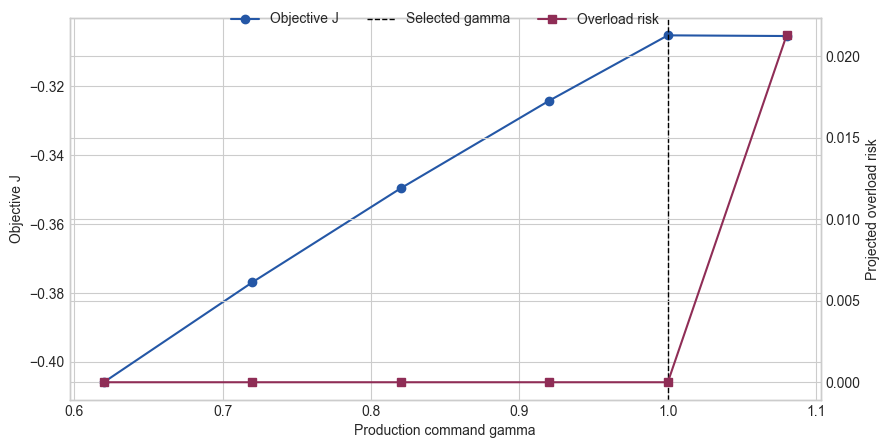

In [3]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(candidates['gamma'], candidates['cost_J'], marker='o', color='#2457a6', label='Objective J')
ax1.set_xlabel('Production command gamma')
ax1.set_ylabel('Objective J')
ax2 = ax1.twinx()
ax2.plot(candidates['gamma'], candidates['overload_risk'], marker='s', color='#8f2d56', label='Overload risk')
ax2.set_ylabel('Projected overload risk')
ax1.axvline(selected_gamma, color='black', linestyle='--', linewidth=1, label='Selected gamma')
fig.legend(loc='upper center', ncol=3)
fig.tight_layout()
fig.savefig(GRAPH_DIR / '05_controller_objective.png', dpi=160)
plt.show()

In [4]:
comparison = []
for mode in ['baseline', 'improved']:
    df = SimulationEngine(SimulationConfig()).run(steps=250, runs=80, mode=mode, seed=99)
    item = performance_summary(df)
    item['mode'] = mode
    comparison.append(item)
pd.DataFrame(comparison)

,mean_reliability,failure_rate,mean_production,production_variance,mean_accuracy,mean_load,mean_throughput,mode
0,0.554,0.446,0.87397,0.050118,0.433477,6.687211,0.367910,baseline
1,0.661,0.339,0.93678,0.047791,0.503496,5.985486,0.461828,improved
